# WR503 上手／下手震動比較：2026-06-03 vs 2026-08-27

比較相同條件的原始／濾波前量測，上手只和上手比、下手只和下手比。所有時間序列圖使用完全相同的 y 軸範圍與刻度，紅色虛線為 ±0.3 g 門檻。六月包含 WPH249 與 WPH250 兩組基準資料。

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.unicode_minus"] = False


In [2]:
DATASETS = {
    "2026-06-03 WPH249 upper/raw": Path(r"C:\ITRI\歐陽\SAA\WR503\震動量測\20260603\WPH249\上手\RecData--20260603142758.csv"),
    "2026-06-03 WPH250 upper/raw": Path(r"C:\ITRI\歐陽\SAA\WR503\震動量測\20260603\WPH250\上手\RecData--20260603153648.csv"),
    "2026-08-27 upper J5/raw": Path(r"C:\ITRI\歐陽\SAA\WR503\震動量測\20260827_vib test\濾波前\上手J5\RecData--20260827115016.csv"),
    "2026-06-03 WPH249 lower/raw": Path(r"C:\ITRI\歐陽\SAA\WR503\震動量測\20260603\WPH249\下手\RecData--20260603142937.csv"),
    "2026-06-03 WPH250 lower/raw": Path(r"C:\ITRI\歐陽\SAA\WR503\震動量測\20260603\WPH250\下手\RecData--20260603153829.csv"),
    "2026-08-27 lower J4/raw": Path(r"C:\ITRI\歐陽\SAA\WR503\震動量測\20260827_vib test\濾波前\下手J4\RecData--20260827115019.csv"),
}
GROUPS = {
    "Upper gripper": [label for label in DATASETS if "upper" in label],
    "Lower gripper": [label for label in DATASETS if "lower" in label],
}
THRESHOLD_G = 0.3
Y_PADDING_RATIO = 0.03  # Add 3% beyond the largest absolute value
Y_TICK_STEP_G = 0.2     # Common, readable tick spacing
DISPLAY_MAX_POINTS = 60_000

missing = [str(path) for path in DATASETS.values() if not path.exists()]
if missing:
    raise FileNotFoundError("Missing CSV:\n" + "\n".join(missing))


In [3]:
def load_recdata(path):
    with path.open("r", encoding="utf-8-sig", errors="replace") as stream:
        preview = [stream.readline() for _ in range(30)]
    header_row = next(
        i for i, line in enumerate(preview)
        if "time" in line.lower() and "," in line
    )
    metadata = {}
    for line in preview[:header_row]:
        if ":" in line:
            key, value = line.split(":", 1)
            metadata[key.strip()] = value.strip()
    frame = pd.read_csv(path, skiprows=header_row)
    frame.columns = frame.columns.str.strip()
    frame = frame.rename(columns={"Time": "time_s", "X-axis": "X", "Y-axis": "Y", "Z-axis": "Z"})
    required = ["time_s", "X", "Y", "Z"]
    if not set(required).issubset(frame.columns):
        raise ValueError(f"Unexpected columns in {path}: {list(frame.columns)}")
    frame = frame[required].apply(pd.to_numeric, errors="coerce").dropna()
    frame = frame.sort_values("time_s").drop_duplicates("time_s")
    return frame, metadata

series = {}
metadata = {}
for label, path in DATASETS.items():
    series[label], metadata[label] = load_recdata(path)
    print(f"{label}: {len(series[label]):,} samples, {series[label].time_s.iloc[-1]:.3f} s, metadata={metadata[label]}")

# Derive one compact symmetric y scale from the largest absolute value in all six datasets.
global_abs_max = max(frame[["X", "Y", "Z"]].abs().to_numpy().max() for frame in series.values())
Y_LIMIT_G = np.ceil(global_abs_max * (1 + Y_PADDING_RATIO) / 0.1) * 0.1
Y_TICKS_G = np.arange(-Y_LIMIT_G, Y_LIMIT_G + Y_TICK_STEP_G / 2, Y_TICK_STEP_G)
print(f"Common y range: {-Y_LIMIT_G:.1f} to {Y_LIMIT_G:.1f} g; ticks every {Y_TICK_STEP_G:.1f} g (global max |g|={global_abs_max:.6f})")


2026-06-03 WPH249 upper/raw: 374,784 samples, 365.999 s, metadata={}
2026-06-03 WPH250 upper/raw: 377,856 samples, 368.999 s, metadata={}


2026-08-27 upper J5/raw: 359,936 samples, 351.499 s, metadata={'Date/Time': '2026/08/27 11:50:16', 'SamplingRate': '1024.0', 'SensorMAC': '', 'Unit': 'g'}
2026-06-03 WPH249 lower/raw: 374,272 samples, 365.499 s, metadata={}


2026-06-03 WPH250 lower/raw: 374,784 samples, 365.999 s, metadata={'Date/Time': '2026/06/03 15:38:29', 'SamplingRate': '1024.0', 'SensorMAC': 'D8:07:2E:2C:05:20', 'Unit': 'g'}
2026-08-27 lower J4/raw: 363,520 samples, 354.999 s, metadata={'Date/Time': '2026/08/27 11:50:19', 'SamplingRate': '1024.0', 'SensorMAC': '', 'Unit': 'g'}
Common y range: -1.7 to 1.7 g; ticks every 0.2 g (global max |g|=1.598856)


In [4]:
rows = []
for label, frame in series.items():
    dt = frame.time_s.diff().dropna().median()
    for axis in ["X", "Y", "Z"]:
        values = frame[axis].to_numpy()
        absolute = np.abs(values)
        exceeded = absolute >= THRESHOLD_G  # Vendor requirement is strictly < 0.3 g
        transitions = np.diff(np.r_[False, exceeded, False].astype(np.int8))
        run_lengths = np.flatnonzero(transitions == -1) - np.flatnonzero(transitions == 1)
        event_count = len(run_lengths)
        rows.append({
            "dataset": label,
            "axis": axis,
            "samples": len(values),
            "sampling_rate_Hz": 1 / dt,
            "mean_g": values.mean(),
            "std_g": values.std(ddof=1),
            "RMS_g": np.sqrt(np.mean(values ** 2)),
            "p95_abs_g": np.percentile(absolute, 95),
            "p99_abs_g": np.percentile(absolute, 99),
            "p99.9_abs_g": np.percentile(absolute, 99.9),
            "max_abs_g": absolute.max(),
            "min_g": values.min(),
            "max_g": values.max(),
            "within_0.3g_pct": 100 * np.mean(absolute < THRESHOLD_G),
            "outside_0.3g_count": np.count_nonzero(exceeded),
            "outside_0.3g_pct": 100 * np.mean(exceeded),
            "outside_0.3g_seconds": np.count_nonzero(exceeded) * dt,
            "exceedance_events": event_count,
            "exceedance_events_per_min": event_count / (len(values) * dt / 60),
            "max_exceedance_duration_ms": (run_lengths.max() * dt * 1000) if event_count else 0.0,
        })
metrics = pd.DataFrame(rows).set_index(["dataset", "axis"])
display(metrics.round(6))


samples  sampling_rate_Hz    mean_g  \
dataset                     axis                                        
2026-06-03 WPH249 upper/raw X      374784       1023.992136 -0.000000   
                            Y      374784       1023.992136 -0.000001   
                            Z      374784       1023.992136 -0.000002   
2026-06-03 WPH250 upper/raw X      377856       1023.992136  0.000007   
                            Y      377856       1023.992136 -0.000000   
                            Z      377856       1023.992136  0.000003   
2026-08-27 upper J5/raw     X      359936       1024.000524 -0.000006   
                            Y      359936       1024.000524 -0.000007   
                            Z      359936       1024.000524  0.000001   
2026-06-03 WPH249 lower/raw X      374272       1023.992136  0.000022   
                            Y      374272       1023.992136  0.000001   
                            Z      374272       1023.992136 -0.000003   
2026-06-03 WPH250 lower/raw X      374784       1024.000524 -0.000013   
                            Y      374784       1024.000524 -0.000001   
                            Z      374784       1024.000524 -0.000001   
2026-08-27 lower J4/raw     X      363520       1024.000524 -0.000020   
                            Y      363520       1024.000524  0.000005   
                            Z      363520       1024.000524 -0.000000   

                                     std_g     RMS_g  p95_abs_g  p99_abs_g  \
dataset                     axis                                             
2026-06-03 WPH249 upper/raw X     0.099218  0.099218   0.213899   0.426862   
                            Y     0.100415  0.100414   0.195829   0.406746   
                            Z     0.055208  0.055208   0.104215   0.230146   
2026-06-03 WPH250 upper/raw X     0.098866  0.098866   0.212943   0.426862   
                            Y     0.100451  0.100451   0.194841   0.407319   
                            Z     0.055018  0.055018   0.104478   0.231117   
2026-08-27 upper J5/raw     X     0.100065  0.100065   0.218929   0.395043   
                            Y     0.106029  0.106029   0.218162   0.404311   
                            Z     0.054572  0.054572   0.099186   0.222711   
2026-06-03 WPH249 lower/raw X     0.103136  0.103136   0.213491   0.411163   
                            Y     0.107080  0.107080   0.217012   0.473132   
                            Z     0.061361  0.061361   0.094840   0.226750   
2026-06-03 WPH250 lower/raw X     0.103486  0.103486   0.214995   0.410887   
                            Y     0.107255  0.107255   0.217119   0.473970   
                            Z     0.059736  0.059736   0.094988   0.225700   
2026-08-27 lower J4/raw     X     0.108224  0.108224   0.225666   0.413793   
                            Y     0.136000  0.135999   0.282231   0.568434   
                            Z     0.058328  0.058328   0.089419   0.214505   

                                  p99.9_abs_g  max_abs_g     min_g     max_g  \
dataset                     axis                                               
2026-06-03 WPH249 upper/raw X        0.642953   0.863634 -0.679105  0.863634   
                            Y        0.869722   1.146297 -1.146297  1.117009   
                            Z        0.470046   0.960417 -0.776877  0.960417   
2026-06-03 WPH250 upper/raw X        0.644203   0.869666 -0.695596  0.869666   
                            Y        0.867717   1.154480 -1.154480  1.114385   
                            Z        0.465883   0.717530 -0.692998  0.717530   
2026-08-27 upper J5/raw     X        0.638530   0.811142 -0.804620  0.811142   
                            Y        0.832385   0.964001 -0.964001  0.949299   
                            Z        0.465076   1.127728 -1.092902  1.127728   
2026-06-03 WPH249 lower/raw X        0.802337   0.961311 -0.961311  0.952430   
                            Y        0.834181   1.16

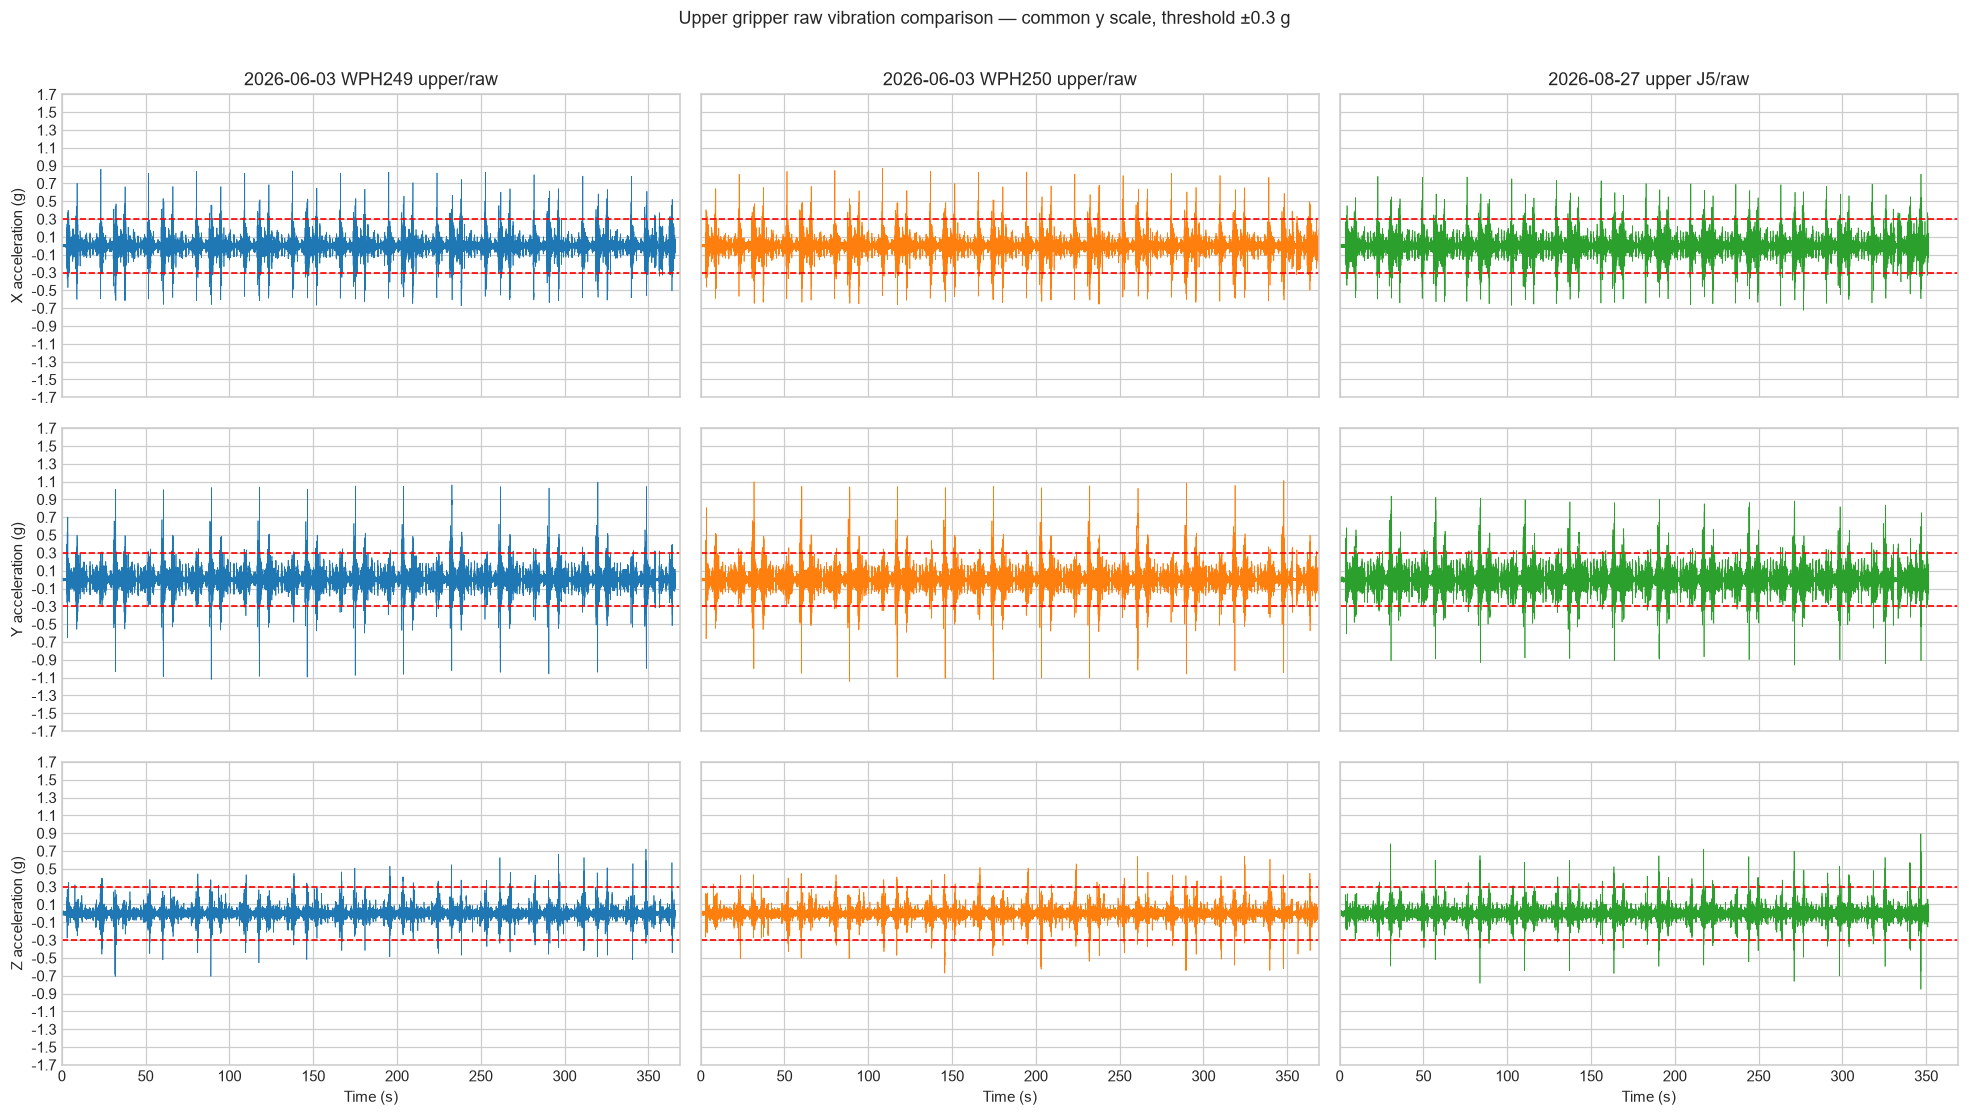

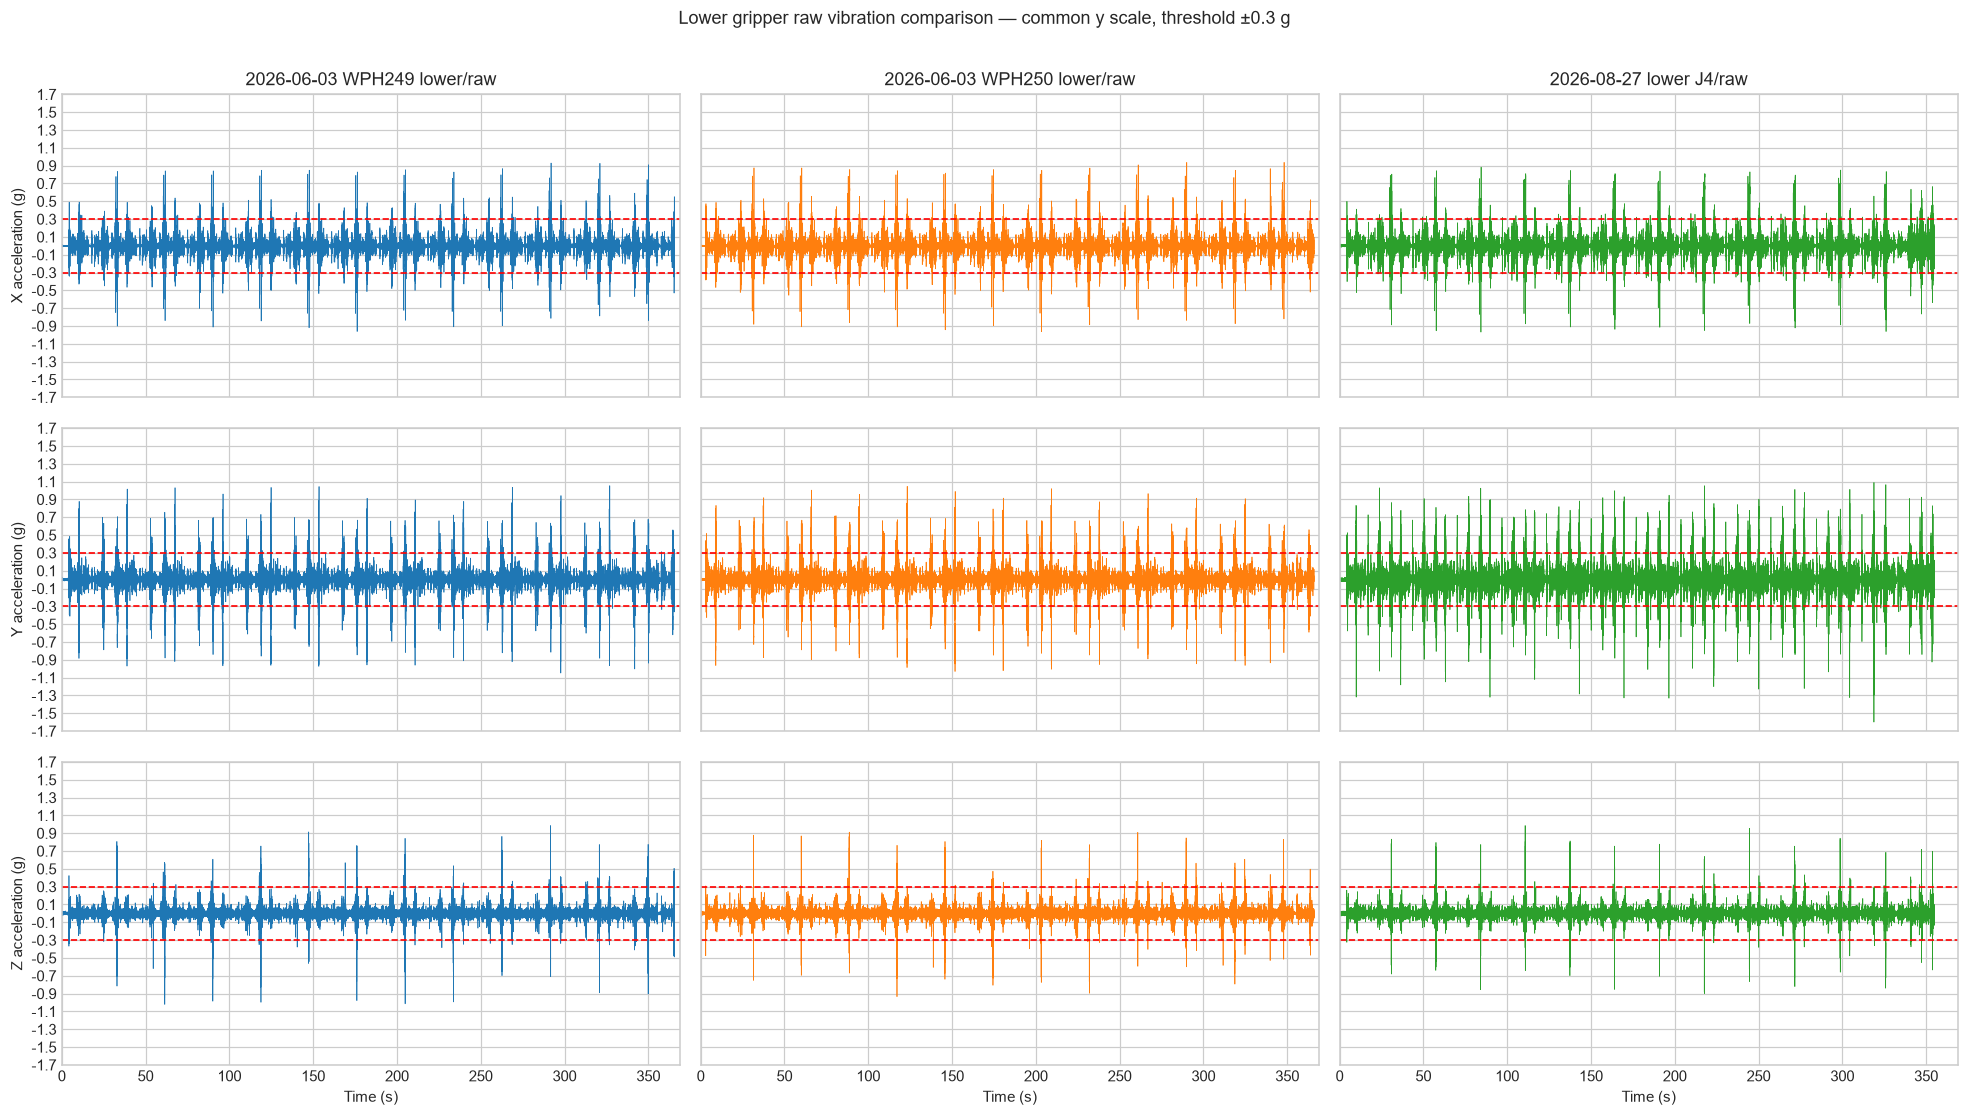

In [5]:
# Rows are axes and columns are dates/runs; upper and lower grippers are separate figures.
axes_names = ["X", "Y", "Z"]
global_duration = max(frame.time_s.iloc[-1] for frame in series.values())
for gripper, labels in GROUPS.items():
    fig, axs = plt.subplots(3, len(labels), figsize=(18, 10), sharex=True, sharey=True, squeeze=False)
    for col, label in enumerate(labels):
        frame = series[label]
        step = max(1, int(np.ceil(len(frame) / DISPLAY_MAX_POINTS)))
        view = frame.iloc[::step]
        for row, axis in enumerate(axes_names):
            ax = axs[row, col]
            ax.plot(view.time_s, view[axis], linewidth=0.45, color=f"C{col}")
            ax.axhline(THRESHOLD_G, color="red", linestyle="--", linewidth=1.1)
            ax.axhline(-THRESHOLD_G, color="red", linestyle="--", linewidth=1.1)
            ax.set_ylim(-Y_LIMIT_G, Y_LIMIT_G)
            ax.set_yticks(Y_TICKS_G)
            ax.set_xlim(0, global_duration)
            if row == 0:
                ax.set_title(label)
            if col == 0:
                ax.set_ylabel(f"{axis} acceleration (g)")
            if row == 2:
                ax.set_xlabel("Time (s)")
    fig.suptitle(f"{gripper} raw vibration comparison — common y scale, threshold ±0.3 g", y=1.01)
    fig.tight_layout()
    plt.show()


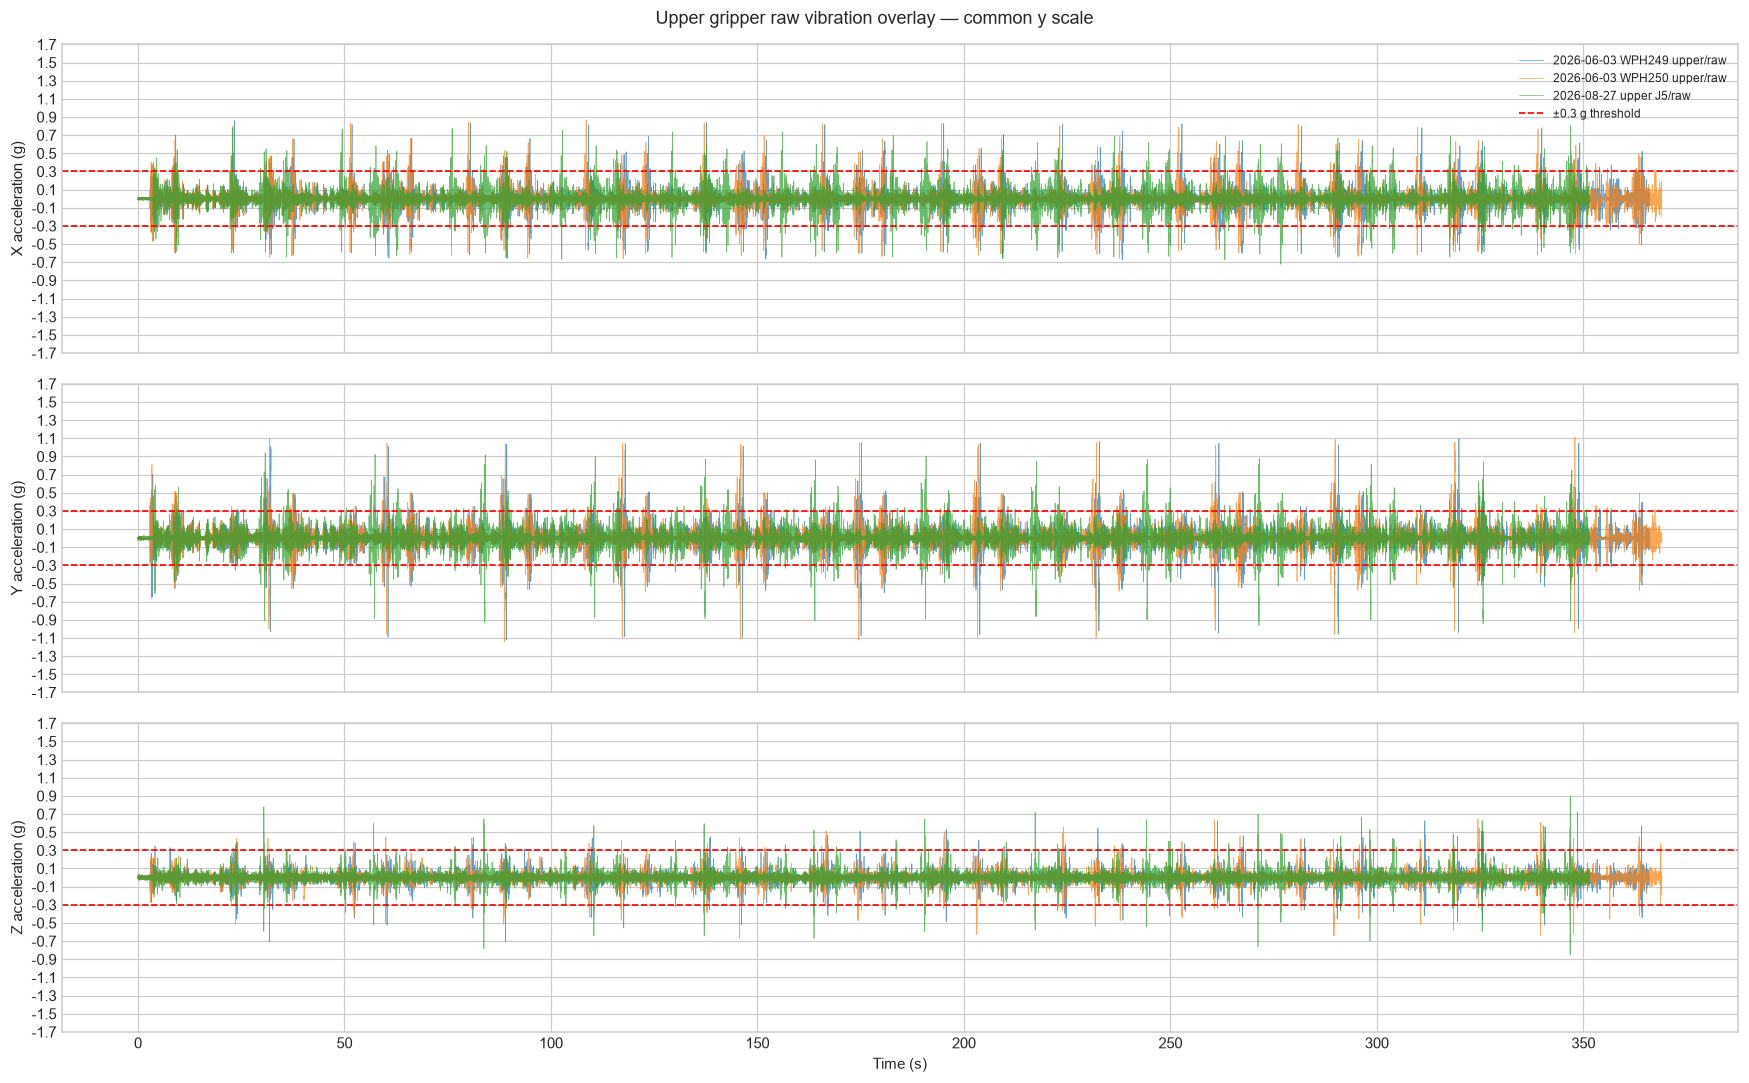

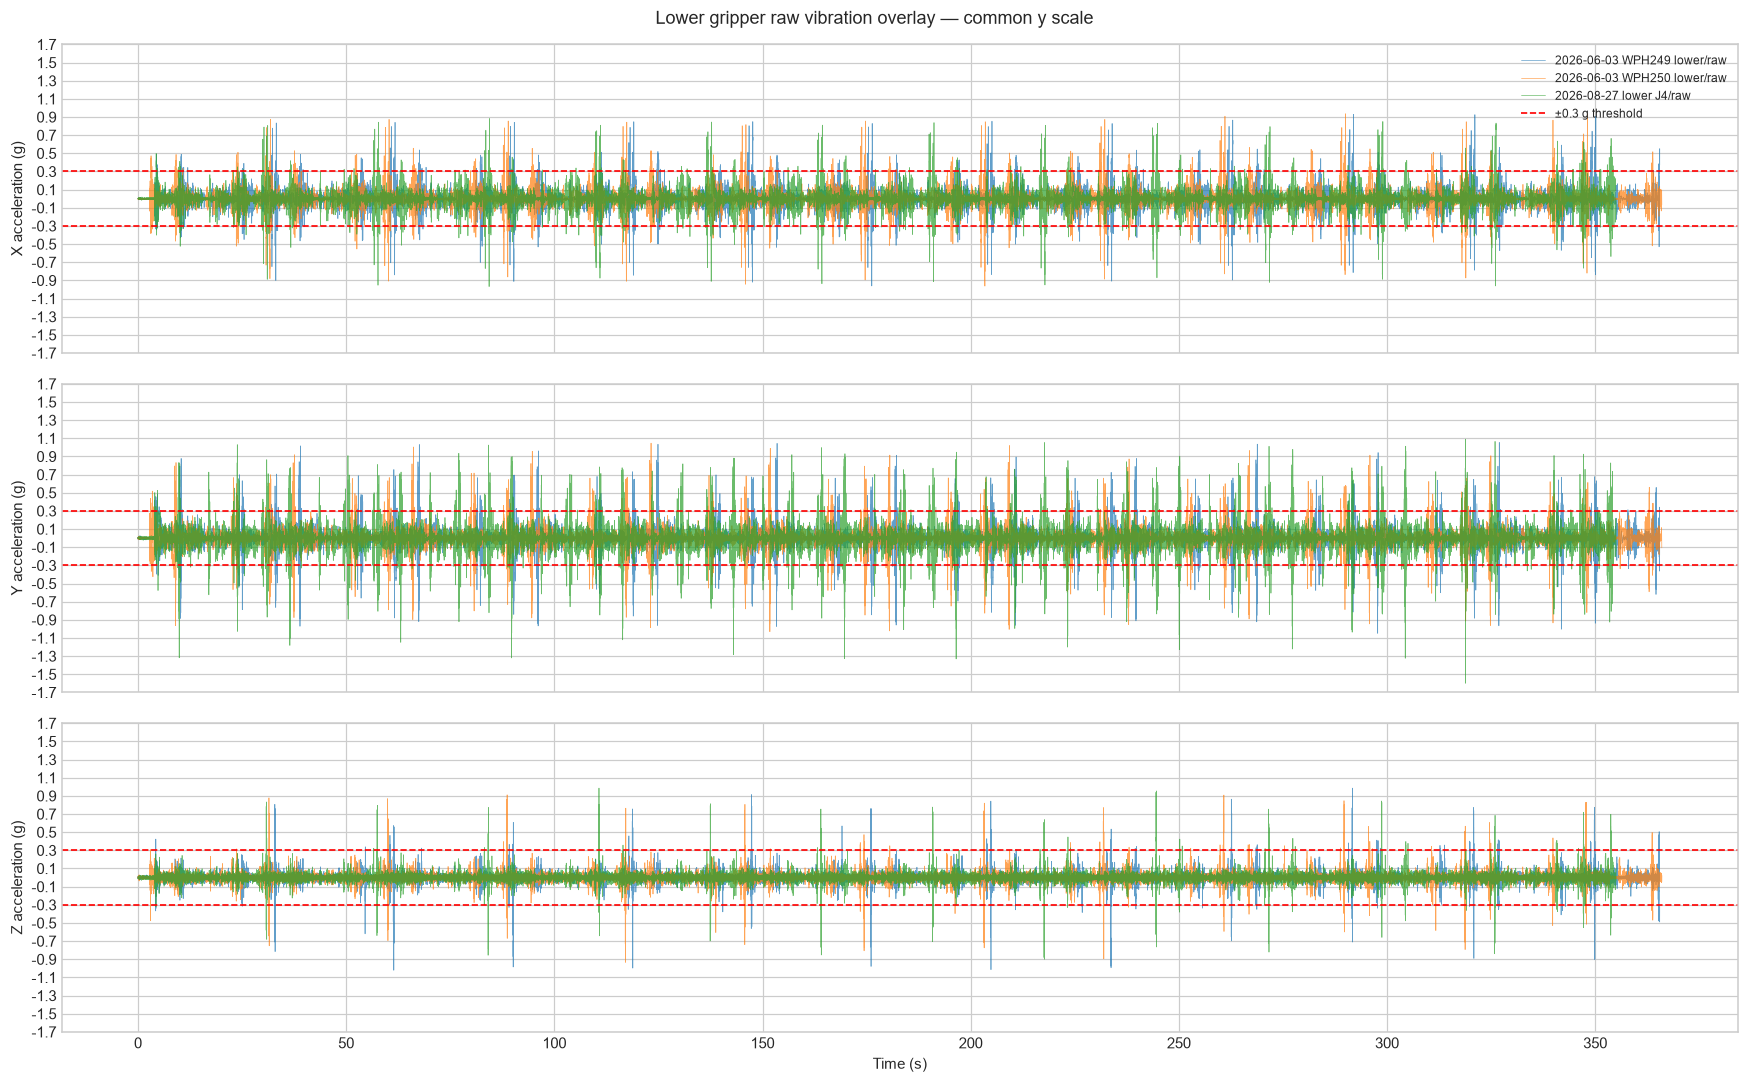

In [6]:
# Overlay view makes amplitude and timing differences easier to compare directly.
for gripper, labels in GROUPS.items():
    fig, axs = plt.subplots(3, 1, figsize=(16, 10), sharex=True, sharey=True)
    for axis, ax in zip(axes_names, axs):
        for label in labels:
            frame = series[label]
            step = max(1, int(np.ceil(len(frame) / DISPLAY_MAX_POINTS)))
            view = frame.iloc[::step]
            ax.plot(view.time_s, view[axis], linewidth=0.45, alpha=0.7, label=label)
        ax.axhline(THRESHOLD_G, color="red", linestyle="--", linewidth=1.1, label="±0.3 g threshold" if axis == "X" else None)
        ax.axhline(-THRESHOLD_G, color="red", linestyle="--", linewidth=1.1)
        ax.set_ylim(-Y_LIMIT_G, Y_LIMIT_G)
        ax.set_yticks(Y_TICKS_G)
        ax.set_ylabel(f"{axis} acceleration (g)")
    axs[0].legend(loc="upper right", fontsize=8)
    axs[-1].set_xlabel("Time (s)")
    fig.suptitle(f"{gripper} raw vibration overlay — common y scale")
    fig.tight_layout()
    plt.show()


RMS_g     min_g     max_g  \
dataset                     axis                                 
2026-06-03 WPH249 upper/raw X     0.099218 -0.679105  0.863634   
                            Y     0.100414 -1.146297  1.117009   
                            Z     0.055208 -0.776877  0.960417   
2026-06-03 WPH250 upper/raw X     0.098866 -0.695596  0.869666   
                            Y     0.100451 -1.154480  1.114385   
                            Z     0.055018 -0.692998  0.717530   
2026-08-27 upper J5/raw     X     0.100065 -0.804620  0.811142   
                            Y     0.106029 -0.964001  0.949299   
                            Z     0.054572 -1.092902  1.127728   
2026-06-03 WPH249 lower/raw X     0.103136 -0.961311  0.952430   
                            Y     0.107080 -1.168597  1.077425   
                            Z     0.061361 -1.144964  1.015008   
2026-06-03 WPH250 lower/raw X     0.103486 -0.962765  0.937088   
                            Y     0.107255 -1.183050  1.101910   
                            Z     0.059736 -1.033211  0.977793   
2026-08-27 lower J4/raw     X     0.108224 -0.995267  0.883119   
                            Y     0.135999 -1.598856  1.128894   
                            Z     0.058328 -1.071680  1.050425   

                                  outside_0.3g_count  outside_0.3g_pct  
dataset                     axis                                        
2026-06-03 WPH249 upper/raw X                   9419          2.513181  
                            Y                   7612          2.031037  
                            Z                   1917          0.511495  
2026-06-03 WPH250 upper/raw X                   9535          2.523448  
                            Y                   7663          2.028021  
                            Z                   1922          0.508659  
2026-08-27 upper J5/raw     X                   8545          2.374033  
                            Y                   8148          2.263736  
                            Z                   1457          0.404794  
2026-06-03 WPH249 lower/raw X                   8589          2.294855  
                            Y                  10914          2.916061  
                            Z                   2282          0.609717  
2026-06-03 WPH250 lower/raw X                   8584          2.290386  
                            Y                  10846          2.893934  
                            Z                   2204          0.588072  
2026-08-27 lower J4/raw     X                   8937          2.458462  
                            Y                  16321          4.489712  
                            Z                   1953          0.537247

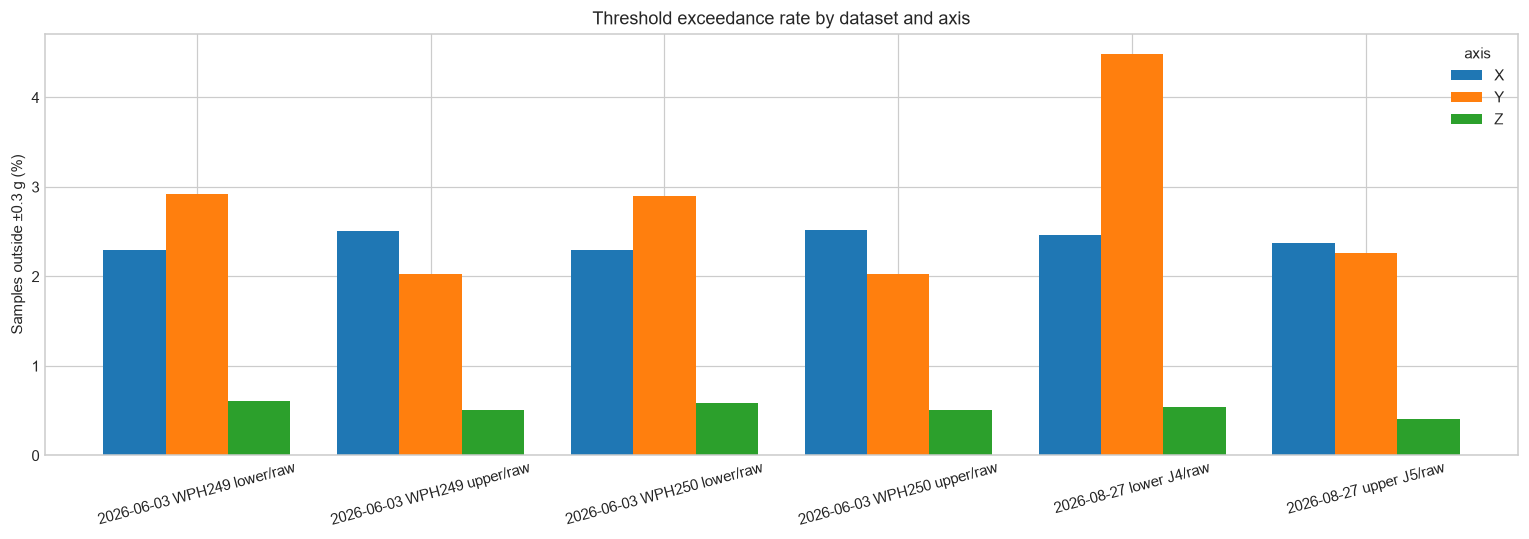

In [7]:
threshold_summary = metrics[["RMS_g", "min_g", "max_g", "outside_0.3g_count", "outside_0.3g_pct"]].copy()
display(threshold_summary.round(6))
ax = threshold_summary["outside_0.3g_pct"].unstack("axis").plot.bar(figsize=(14, 5), width=0.8)
ax.set_ylabel("Samples outside ±0.3 g (%)")
ax.set_xlabel("")
ax.set_title("Threshold exceedance rate by dataset and axis")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()


## Vendor-oriented quantitative improvement

The vendor criterion is strictly **|acceleration| < 0.3 g while transporting 265 wafers**. These recordings were made with 250 wafers, so the tables below quantify improvement after the July mechanical changes but **do not constitute 265-wafer acceptance evidence**. Positive improvement means the August value is lower/better; a negative value means regression.


RMS_g


benchmark  2026-08-27  \
gripper       baseline                    axis                          
Upper gripper 2026-06-03 WPH249 upper/raw X        0.0992      0.1001   
                                          Y        0.1004      0.1060   
                                          Z        0.0552      0.0546   
              2026-06-03 WPH250 upper/raw X        0.0989      0.1001   
                                          Y        0.1005      0.1060   
                                          Z        0.0550      0.0546   
              Mean of baselines           X        0.0990      0.1001   
                                          Y        0.1004      0.1060   
                                          Z        0.0551      0.0546   
Lower gripper 2026-06-03 WPH249 lower/raw X        0.1031      0.1082   
                                          Y        0.1071      0.1360   
                                          Z        0.0614      0.0583   
              2026-06-03 WPH250 lower/raw X        0.1035      0.1082   
                                          Y        0.1073      0.1360   
                                          Z        0.0597      0.0583   
              Mean of baselines           X        0.1033      0.1082   
                                          Y        0.1072      0.1360   
                                          Z        0.0605      0.0583   

                                                improvement_%  
gripper       baseline                    axis                 
Upper gripper 2026-06-03 WPH249 upper/raw X           -0.8542  
                                          Y           -5.5913  
                                          Z            1.1522  
              2026-06-03 WPH250 upper/raw X           -1.2130  
                                          Y           -5.5525  
                                          Z            0.8113  
              Mean of baselines           X           -1.0333  
                                          Y           -5.5719  
                                          Z            0.9820  
Lower gripper 2026-06-03 WPH249 lower/raw X           -4.9332  
                                          Y          -27.0071  
                                          Z            4.9439  
              2026-06-03 WPH250 lower/raw X           -4.5786  
                                          Y          -26.7998  
                                          Z            2.3582  
              Mean of baselines           X           -4.7556  
                                          Y          -26.9034  
                                          Z            3.6684


p99_abs_g


benchmark  2026-08-27  \
gripper       baseline                    axis                          
Upper gripper 2026-06-03 WPH249 upper/raw X        0.4269      0.3950   
                                          Y        0.4067      0.4043   
                                          Z        0.2301      0.2227   
              2026-06-03 WPH250 upper/raw X        0.4269      0.3950   
                                          Y        0.4073      0.4043   
                                          Z        0.2311      0.2227   
              Mean of baselines           X        0.4269      0.3950   
                                          Y        0.4070      0.4043   
                                          Z        0.2306      0.2227   
Lower gripper 2026-06-03 WPH249 lower/raw X        0.4112      0.4138   
                                          Y        0.4731      0.5684   
                                          Z        0.2267      0.2145   
              2026-06-03 WPH250 lower/raw X        0.4109      0.4138   
                                          Y        0.4740      0.5684   
                                          Z        0.2257      0.2145   
              Mean of baselines           X        0.4110      0.4138   
                                          Y        0.4736      0.5684   
                                          Z        0.2262      0.2145   

                                                improvement_%  
gripper       baseline                    axis                 
Upper gripper 2026-06-03 WPH249 upper/raw X            7.4542  
                                          Y            0.5985  
                                          Z            3.2304  
              2026-06-03 WPH250 upper/raw X            7.4542  
                                          Y            0.7384  
                                          Z            3.6369  
              Mean of baselines           X            7.4542  
                                          Y            0.6685  
                                          Z            3.4341  
Lower gripper 2026-06-03 WPH249 lower/raw X           -0.6397  
                                          Y          -20.1430  
                                          Z            5.4000  
              2026-06-03 WPH250 lower/raw X           -0.7072  
                                          Y          -19.9304  
                                          Z            4.9600  
              Mean of baselines           X           -0.6734  
                                          Y          -20.0366  
                                          Z            5.1805


p99.9_abs_g


...

benchmark  2026-08-27  \
gripper       baseline                    axis                          
Upper gripper 2026-06-03 WPH249 upper/raw X      171.6380    203.9830   
                                          Y      151.1464    150.8962   
                                          Z      158.6873    126.4866   
              2026-06-03 WPH250 upper/raw X      170.5678    203.9830   
                                          Y      145.6899    150.8962   
                                          Z      158.5354    126.4866   
              Mean of baselines           X      171.1029    203.9830   
                                          Y      148.4182    150.8962   
                                          Z      158.6113    126.4866   
Lower gripper 2026-06-03 WPH249 lower/raw X      163.3366    139.7747   
                                          Y      213.4047    322.4790   
                                          Z      151.5173    130.8170   
              2026-06-03 WPH250 lower/raw X      161.1476    139.7747   
                                          Y      206.3935    322.4790   
                                          Z      143.9345    130.8170   
              Mean of baselines           X      162.2421    139.7747   
                                          Y      209.8991    322.4790   
                                          Z      147.7259    130.8170   

                                                improvement_%  
gripper       baseline                    axis                 
Upper gripper 2026-06-03 WPH249 upper/raw X          -18.8449  
                                          Y            0.1655  
                                          Z           20.2920  
              2026-06-03 WPH250 upper/raw X          -19.5906  
                                          Y           -3.5735  
                                          Z           20.2156  
              Mean of baselines           X          -19.2166  
                                          Y           -1.6697  
                                          Z           20.2538  
Lower gripper 2026-06-03 WPH249 lower/raw X           14.4254  
                                          Y          -51.1115  
                                          Z           13.6620  
              2026-06-03 WPH250 lower/raw X           13.2629  
                                          Y          -56.2447  
                                          Z            9.1135  
              Mean of baselines           X           13.8481  
                                          Y          -53.6353  
                                          Z           11.4462


max_exceedance_duration_ms


benchmark  2026-08-27  \
gripper       baseline                    axis                          
Upper gripper 2026-06-03 WPH249 upper/raw X      104.4930     73.2422   
                                          Y       99.6101    102.5390   
                                          Z       12.6954      9.7656   
              2026-06-03 WPH250 upper/raw X      107.4227     73.2422   
                                          Y       97.6570    102.5390   
                                          Z       13.6720      9.7656   
              Mean of baselines           X      105.9578     73.2422   
                                          Y       98.6336    102.5390   
                                          Z       13.1837      9.7656   
Lower gripper 2026-06-03 WPH249 lower/raw X       90.8210    107.4218   
                                          Y       71.2896     43.9453   
                                          Z       13.6720     15.6250   
              2026-06-03 WPH250 lower/raw X       93.7500    107.4218   
                                          Y       75.1953     43.9453   
                                          Z       13.6719     15.6250   
              Mean of baselines           X       92.2855    107.4218   
                                          Y       73.2424     43.9453   
                                          Z       13.6719     15.6250   

                                                improvement_%  
gripper       baseline                    axis                 
Upper gripper 2026-06-03 WPH249 upper/raw X           29.9071  
                                          Y           -2.9403  
                                          Z           23.0776  
              2026-06-03 WPH250 upper/raw X           31.8187  
                                          Y           -4.9991  
                                          Z           28.5720  
              Mean of baselines           X           30.8761  
                                          Y           -3.9595  
                                          Z           25.9265  
Lower gripper 2026-06-03 WPH249 lower/raw X          -18.2786  
                                          Y           38.3567  
                                          Z          -14.2848  
              2026-06-03 WPH250 lower/raw X          -14.5833  
                                          Y           41.5584  
                                          Z          -14.2857  
              Mean of baselines           X          -16.4016  
                                          Y           40.0002  
                                          Z          -14.2852

August 250-wafer threshold evidence (not a 265-wafer acceptance test):


within_0.3g_pct  outside_0.3g_count  \
dataset                 axis                                        
2026-08-27 upper J5/raw X           97.625967                8545   
                        Y           97.736264                8148   
                        Z           99.595206                1457   
2026-08-27 lower J4/raw X           97.541538                8937   
                        Y           95.510288               16321   
                        Z           99.462753                1953   

                              outside_0.3g_seconds  max_abs_g  \
dataset                 axis                                    
2026-08-27 upper J5/raw X                 8.344722   0.811142   
                        Y                 7.957027   0.964001   
                        Z                 1.422851   1.127728   
2026-08-27 lower J4/raw X                 8.727535   0.995267   
                        Y                15.938468   1.598856   
                        Z                 1.907226   1.071680   

                              all_samples_strictly_below_0.3g  
dataset                 axis                                   
2026-08-27 upper J5/raw X                               False  
                        Y                               False  
                        Z                               False  
2026-08-27 lower J4/raw X                               False  
                        Y                               False  
                        Z                               False

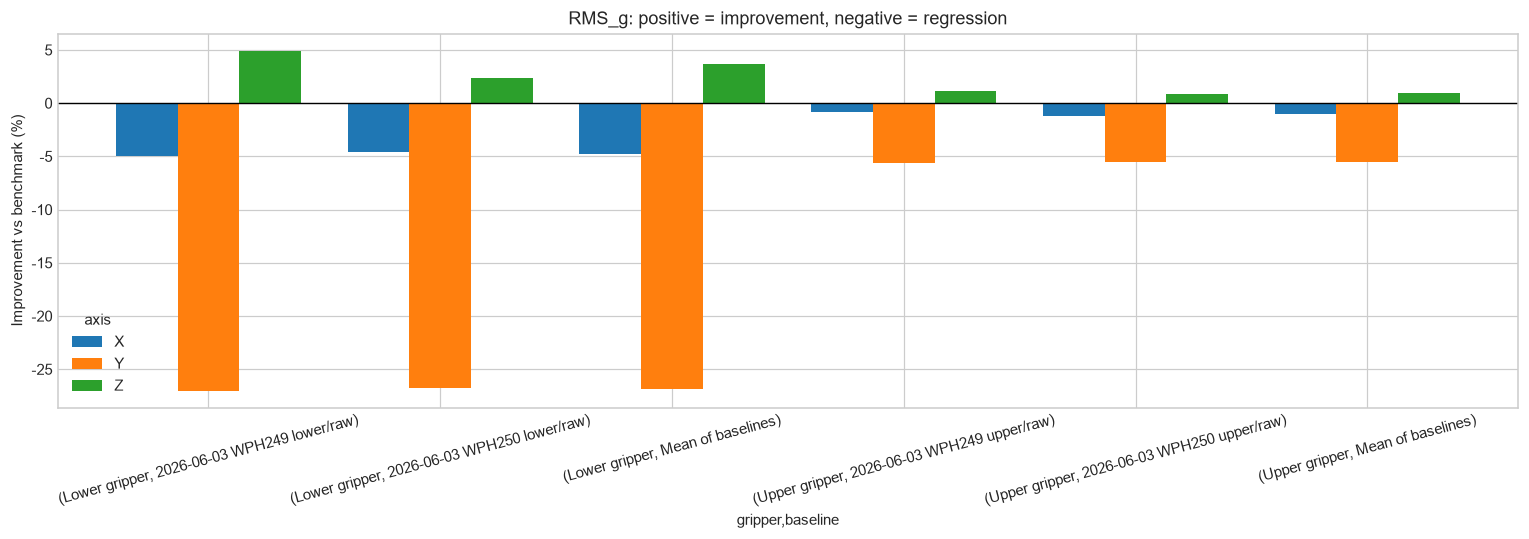

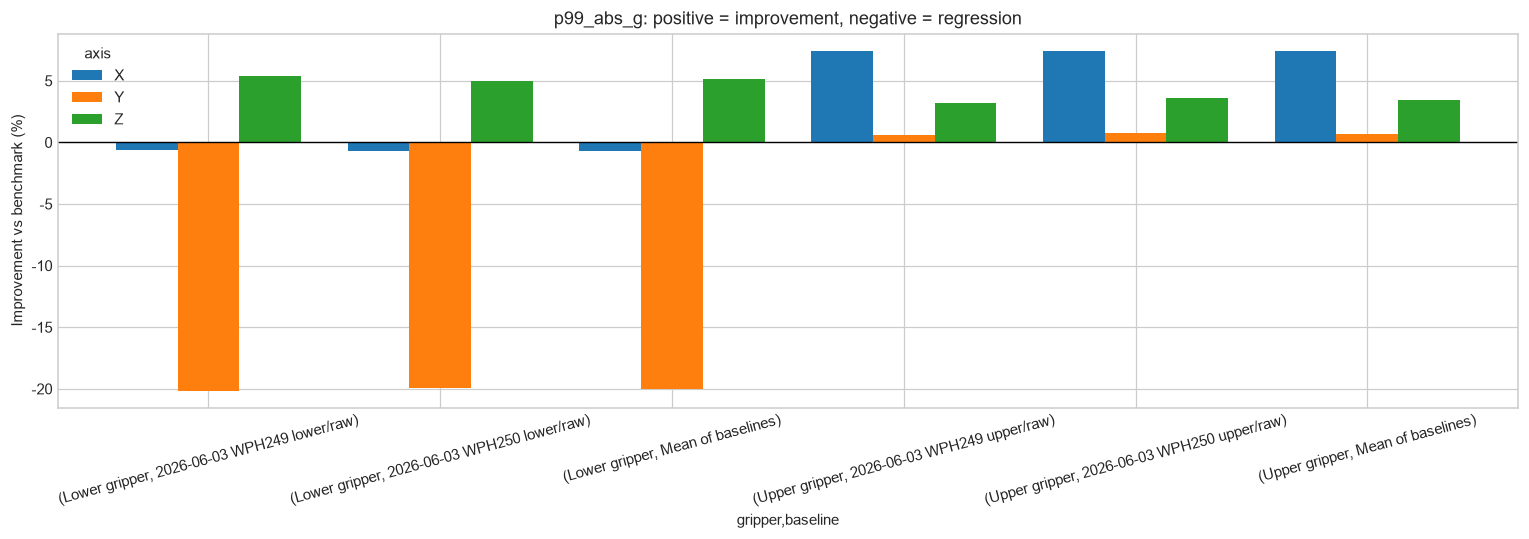

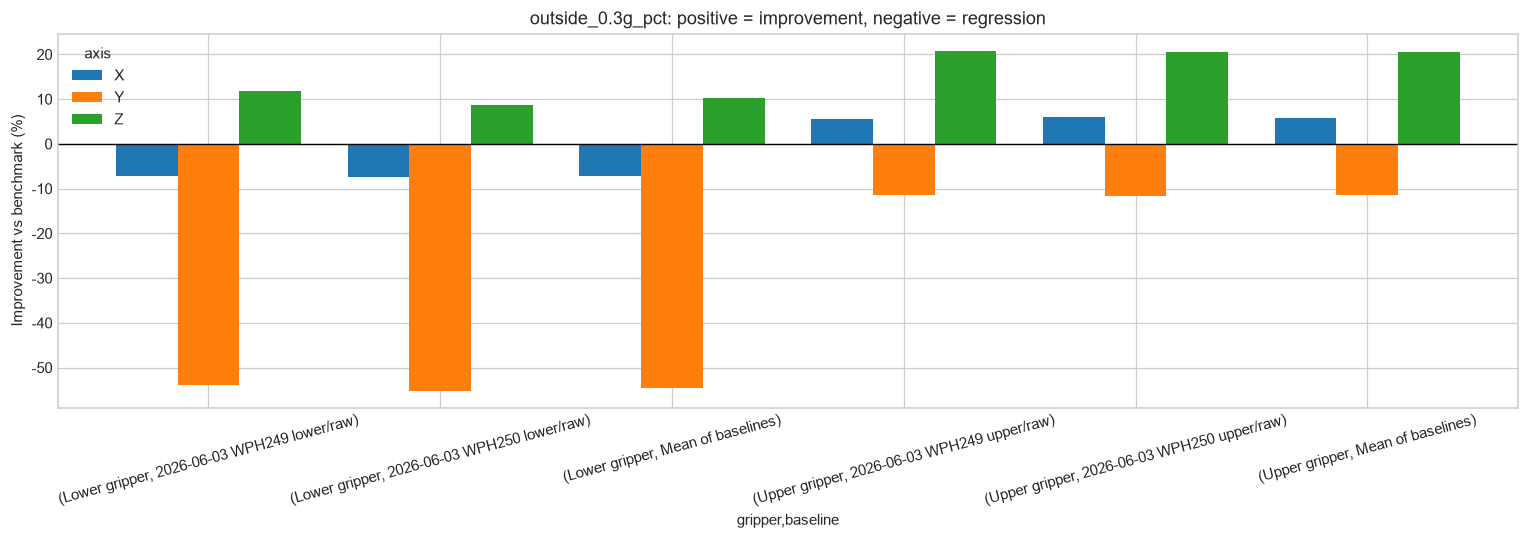

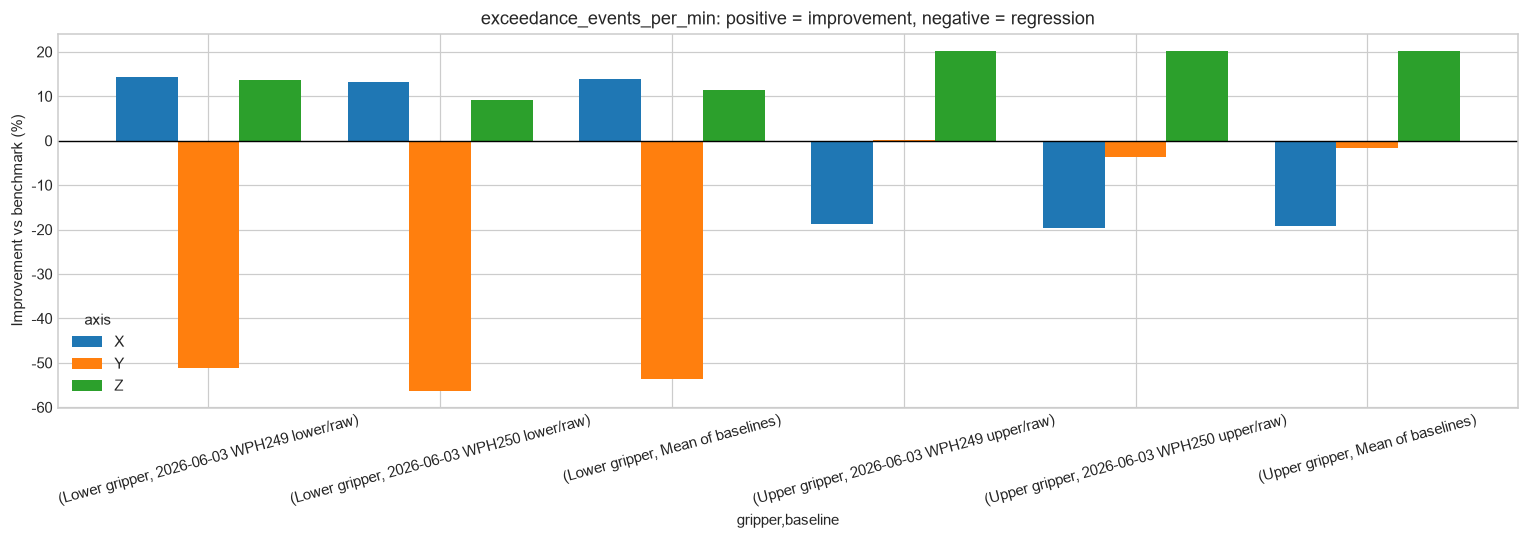

In [8]:
LOWER_IS_BETTER = [
    "RMS_g", "p99_abs_g", "p99.9_abs_g", "max_abs_g",
    "outside_0.3g_pct", "exceedance_events_per_min", "max_exceedance_duration_ms",
]
comparison_rows = []
for gripper, labels in GROUPS.items():
    current_label = next(label for label in labels if "2026-08-27" in label)
    baseline_labels = [label for label in labels if label != current_label]
    baseline_sets = [(label, metrics.loc[label]) for label in baseline_labels]
    if len(baseline_labels) > 1:
        baseline_sets.append(("Mean of baselines", pd.concat([metrics.loc[label] for label in baseline_labels]).groupby(level=0).mean()))
    current = metrics.loc[current_label]
    for baseline_name, baseline in baseline_sets:
        for axis in ["X", "Y", "Z"]:
            row = {"gripper": gripper, "baseline": baseline_name, "axis": axis}
            for metric in LOWER_IS_BETTER:
                old, new = baseline.loc[axis, metric], current.loc[axis, metric]
                row[f"{metric}__baseline"] = old
                row[f"{metric}__august"] = new
                row[f"{metric}__improvement_pct"] = 100 * (old - new) / old if old != 0 else np.nan
            comparison_rows.append(row)
improvement = pd.DataFrame(comparison_rows).set_index(["gripper", "baseline", "axis"])

for metric in LOWER_IS_BETTER:
    print(f"\n{metric}")
    display(improvement[[f"{metric}__baseline", f"{metric}__august", f"{metric}__improvement_pct"]]
            .rename(columns={f"{metric}__baseline": "benchmark", f"{metric}__august": "2026-08-27", f"{metric}__improvement_pct": "improvement_%"})
            .round(4))

current_labels = [label for label in metrics.index.get_level_values(0).unique() if "2026-08-27" in label]
acceptance = metrics.loc[current_labels, ["within_0.3g_pct", "outside_0.3g_count", "outside_0.3g_seconds", "max_abs_g"]].copy()
acceptance["all_samples_strictly_below_0.3g"] = acceptance["outside_0.3g_count"].eq(0)
print("August 250-wafer threshold evidence (not a 265-wafer acceptance test):")
display(acceptance.round(6))

for metric in ["RMS_g", "p99_abs_g", "outside_0.3g_pct", "exceedance_events_per_min"]:
    chart = improvement[f"{metric}__improvement_pct"].unstack("axis")
    ax = chart.plot.bar(figsize=(14, 5), width=0.8)
    ax.axhline(0, color="black", linewidth=0.9)
    ax.set_ylabel("Improvement vs benchmark (%)")
    ax.set_title(f"{metric}: positive = improvement, negative = regression")
    ax.tick_params(axis="x", rotation=15)
    plt.tight_layout()
    plt.show()
